## Imports

In [146]:
import pandas as pd
import os
from pathlib import Path
from reload_recursive import reload_recursive
from tqdm.notebook import tqdm

from helpers.parallel import BetterPool

from collections import defaultdict

import scripts.compile_run_metrics
import helpers.utils
import scripts.inference
from IPython.display import clear_output

In [147]:
reload_recursive(scripts.compile_run_metrics)
#TODO Thi
from scripts.compile_run_metrics import EXPERIMENT_KEYS

reload_recursive(scripts.inference)
from scripts.inference import uncrop_predictions

import analysis.image
reload_recursive(analysis.image)
from analysis.image import lesion_analysis as lesion_dx
from analysis.image import classify

reload_recursive(helpers.utils)
from helpers.utils import dice_score, get_prl_indices

import helpers.shell_interface
reload_recursive(helpers.shell_interface)
from helpers.shell_interface import open_itksnap_workspace_cmd

import core.dataset
reload_recursive(core.dataset)
from core.dataset import Dataset

import core.experiment
reload_recursive(core.experiment)
from core.experiment import Experiment
from loguru import logger

import scripts
reload_recursive(scripts)
# from scripts import lesion_diagnostics as lesion_dx
from scripts.compile_run_metrics import load_or_cache_run

In [148]:
analysis_dir = Path("/home/srs-9/Projects/prl_project/analysis")

## Analysis

### Inference Set 1

In [149]:
data = pd.read_csv("/home/srs-9/Projects/thalamus_project/data/working_data_wide3.csv", index_col="subid")
train_dataset_name = "roi_train2"
train_dataset = Dataset(train_dataset_name)

experiment_key, run_name = "stage6", "run1"
experiment_name = f"{EXPERIMENT_KEYS[experiment_key]}/{run_name}"
experiment = Experiment.from_run_dir(experiment_name, train_dataset)
experiment_name = experiment.name.replace("/", "_")


expand_xy: int = experiment.preprocess_config.expand_xy
expand_z: int = experiment.preprocess_config.expand_z
images: tuple[str, ...] = experiment.preprocess_config.images

train_radiomic_df = pd.read_csv(
    analysis_dir / f"prl_image_stats-{train_dataset_name}_{experiment_name}.csv"
)

inference_dataset = Dataset("inference_dataset")
datafile_name = f"prl_{inference_dataset.name}_image_stats-{train_dataset_name}_{experiment_name}.csv"
inf_radiomics_df = pd.read_csv(analysis_dir/datafile_name)

full_inference_dataset = Dataset("full_inference_dataset")
datafile_name = f"prl_{full_inference_dataset.name}_image_stats-{train_dataset_name}_{experiment_name}.csv"
full_inf_radiomics_df = pd.read_csv(analysis_dir/datafile_name)

# these are already filtered for "has_iron_infer"
large_train_df = pd.concat([train_radiomic_df, inf_radiomics_df], axis=0, ignore_index=True)

In [150]:
full_inference_subjects = full_inference_dataset.cases.index.get_level_values("subid").unique()
print(len(full_inference_subjects))
print(len(full_inference_dataset.cases))
prl_df = full_inference_dataset.prl_df
prl_df.loc[full_inference_subjects, "PRL"].sum()

371
21666


np.float64(218.0)

In [151]:
train_subjeccts = train_dataset.cases.index.get_level_values("subid").unique()
print(len(train_subjeccts))
print(prl_df.loc[train_subjeccts, "PRL"].sum())
print(len(train_dataset.cases))

24
53.0
991


In [152]:
inference_subjects = inference_dataset.cases.index.get_level_values("subid").unique()
print(len(inference_subjects))
print(len(inference_dataset.cases))
prl_df.loc[inference_subjects, "PRL"].sum()

52
3912


np.float64(127.0)

In [153]:
all_subs = set(full_inference_subjects) | set(train_subjeccts) | set(inference_subjects)
len(all_subs)

447

In [154]:
from scipy import stats


stats.scoreatpercentile(data.loc[data.index.isin(list(all_subs)), "PRL"], 75)

np.float64(1.0)

In [155]:
data

,subject,sz_onset,dzdur,MSSS,gMSSS,ARMSS,sex,age,obs_start_date,obs_end_date,...,CIS,PPMS,PRMS,RIS,RPMS,RRMS,SPMS,dGMV,cGMV,dzdur2
subid,,,,,,,,,,,,,,,,,,,,,
1001,ms1001,2/1/2003,14.039699,1.03,1.68,1.56,Female,50.057493,2/15/2017,2/15/2017,...,False,False,False,False,False,True,False,17236.174364,464080.845177,14.039699
1002,ms1002,4/1/2019,1.138946,4.30,4.31,4.63,Female,27.079341,5/21/2020,5/21/2020,...,False,False,False,False,False,True,False,24717.917606,458268.700972,1.138946
1003,ms1003,1/1/2003,14.239562,6.56,7.34,4.53,Female,68.044680,3/29/2017,3/29/2017,...,False,True,False,False,False,False,False,21580.450704,458878.583331,14.239562
1004,ms1004,10/1/2015,3.931554,2.87,3.65,4.53,Female,28.188140,9/6/2019,9/6/2019,...,False,False,False,False,False,True,False,18638.800605,369220.807073,3.931554
1005,ms1005,1/1/2001,19.515400,2.99,4.25,6.01,Female,47.059629,7/8/2020,7/8/2020,...,False,True,False,False,False,False,False,15736.152079,412716.098782,19.515400
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3016,ms3016,6/1/2008,9.204654,2.65,3.41,3.73,Female,41.389695,8/15/2017,8/15/2017,...,False,False,False,False,False,True,False,15427.544618,383043.800671,9.204654
3017,ms3017,1/1/1998,19.118412,1.00,1.77,1.75,Female,56.179160,2/13/2017,2/13/2017,...,False,False,False,False,False,True,False,20848.020036,561900.366828,19.118412
3021,ms3021,1/1/1998,18.877481,5.35,6.37,6.55,Female,56.351640,11/17/2016,11/17/2016,...,False,False,False,False,False,True,False,18057.284346,405025.541565,18.877481


In [156]:
prl_df.loc[data[data['dz_type2']=="MS"].index, 'PRL'].sum()

np.float64(418.0)

In [157]:
len(full_inference_subjects) + len(train_subjeccts) + len(inference_subjects)

447

In [158]:
len(prl_df)

575


--- Test set ---
              precision    recall  f1-score   support

      Lesion       0.91      0.84      0.87        99
         PRL       0.67      0.80      0.73        40

    accuracy                           0.83       139
   macro avg       0.79      0.82      0.80       139
weighted avg       0.84      0.83      0.83       139

ROC-AUC: 0.880


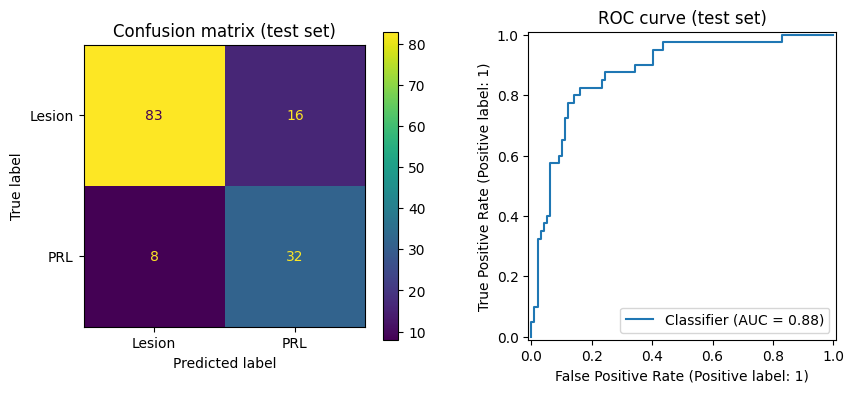

In [142]:
X_train, X_test, y_train, y_test = classify.prepare_data(large_train_df)
model = classify.train_model(X_train, y_train)
fig, axes = classify.evaluate_model(model, X_test, y_test, display=True, to_print=True, return_fig=True)

In [143]:
fig.savefig("classifier pereformance.png", dpi=600, transparent=True)

In [ ]:
fig, ax, coef_df = classify.plot_logistic_coefficients(
    model,
    title="Radiomic classifier feature weights",
    sort_by="coef",
    figsize=(5.8, 4.2),
    savepath="radiomic_classifier_coefficients.png",
)

plt.show()


--- Test set ---
              precision    recall  f1-score   support

      Lesion       0.91      0.84      0.87        99
         PRL       0.67      0.80      0.73        40

    accuracy                           0.83       139
   macro avg       0.79      0.82      0.80       139
weighted avg       0.84      0.83      0.83       139

ROC-AUC: 0.880

--- Feature coefficients (log-odds) ---
                feature      coef
       rim_volume_infer  2.561644
             std_radius  1.015812
         pca_sphericity  0.926491
  rim_hull_volume_infer -0.717702
            mean_radius -0.524004
             max_radius -0.467213
             min_radius  0.378389
          pca_linearity -0.236874
rim_sphere_radius_infer -0.234414
          pca_planarity -0.160162
              radial_cv -0.095186
               pca_size -0.055784


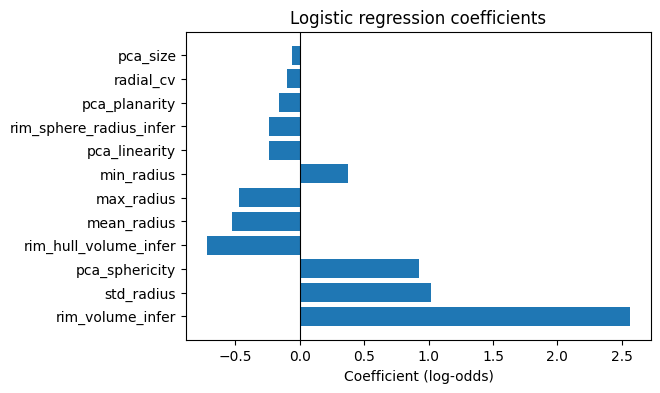

In [144]:
fig, axes = classify.evaluate_model(model, X_test, y_test, display_coef=True, to_print=True, return_fig=True)

In [145]:
fig.savefig("classification_feature_coefficients.png", dpi=600, transparent=True)

In [75]:
# Go down as far as it will allow on test size to create the model I will apply to the other full dataset
X_train, _, y_train, _ = classify.prepare_data(large_train_df, test_size=0)

# ik this is double dipping, but its just so I can get volumes of rim, not to evaluate model performance
all_subject_radiomics = pd.concat([large_train_df, full_inf_radiomics_df], axis=0, ignore_index=True)
_, X_test, _, y_test = classify.prepare_data(all_subject_radiomics, test_size=1)

model = classify.train_model(X_train, y_train)
y_pred, y_prob = classify.evaluate_model(model, X_test, y_test)
all_subject_radiomics['isPRL_infer'] = y_pred
all_subject_radiomics['isPRL_prob'] = y_prob

In [76]:
all_subject_radiomics.groupby("subid")['isPRL_infer'].sum()

subid
1001    0
1002    4
1003    0
1004    0
1005    2
       ..
3016    0
3017    0
3021    0
3023    1
3028    0
Name: isPRL_infer, Length: 393, dtype: int64

In [77]:
final_rim_volumes = all_subject_radiomics[all_subject_radiomics['isPRL_infer']==1].groupby("subid")['rim_volume_infer'].sum()
final_lesion_volumes = all_subject_radiomics[all_subject_radiomics['isPRL_infer']==1].groupby("subid")['lesion_volume_infer'].sum()

df = full_inference_dataset.prl_df.copy()
df['rim_volume'] = 0.0
df.loc[final_rim_volumes.index, 'rim_volume'] = final_rim_volumes

df['nPRL_infer'] = 0
df['nPRL_infer'] = all_subject_radiomics.groupby("subid")['isPRL_infer'].sum()

In [78]:
df.loc[1126, :]

PRL_possible              2
PRL_probable              3
PRL_definite             11
PRL                    14.0
date_mri           20170609
Total PRL              14.0
PRL1_label             23.0
PRL2_label              5.0
PRL3_label             18.0
PRL4_label             15.0
PRL5_label              6.0
PRL6_label             13.0
PRL7_label              4.0
PRL8_label              7.0
PRL9_label              1.0
PRL10_label             2.0
PRL11_label             2.0
PRL12_label             2.0
PRL13_label             2.0
PRL14_label             2.0
PRL15_label             1.0
PRL16_label             9.0
PRL17_label             NaN
PRL18_label             NaN
PRL19_label             NaN
PRL20_label             NaN
confidence.0       definite
confidence.1       definite
confidence.2       definite
confidence.3       possible
confidence.4       definite
confidence.5       probable
confidence.6       definite
confidence.7       probable
confidence.8       definite
confidence.9       d

[Text(0, 0, ''),
 Text(1, 0, ''),
 Text(2, 0, ''),
 Text(3, 0, ''),
 Text(4, 0, ''),
 Text(5, 0, ''),
 Text(6, 0, ''),
 Text(7, 0, ''),
 Text(8, 0, ''),
 Text(9, 0, ''),
 Text(10, 0, ''),
 Text(11, 0, ''),
 Text(12, 0, ''),
 Text(13, 0, '')]

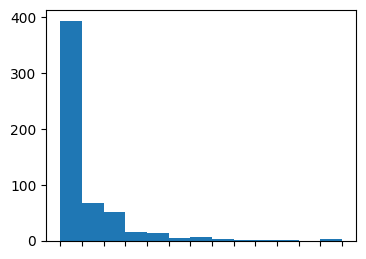

In [79]:
import numpy as np
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, figsize=(4,3))
ax.hist(df['PRL'], bins=np.arange(0, 14, 1))
# plt.axes(visible=False)
# ax.set_yticklabels([])
ax.set_xticks(np.arange(0, 14, 1))
ax.set_xticklabels([])
# fig.savefig("PRL hist.png", transparent=True, dpi=600)

In [80]:
all_subject_radiomics

,subid,lesion_index,case_type,has_iron_infer,rim_voxels_infer,rim_volume_infer,rim_hull_volume_infer,rim_sphere_radius_infer,lesion_voxels_infer,lesion_volume_infer,...,pca_sphericity,pca_planarity,pca_linearity,mean_radius,std_radius,min_radius,max_radius,radial_cv,isPRL_infer,isPRL_prob
0,1033,2,PRL,True,304,155.647610,263.593991,6.260826,530,271.359300,...,0.563239,0.235150,0.201611,4.632045,1.231196,1.825990,7.664771,0.265800,1,0.883458
1,1033,1,Lesion,True,188,96.255760,243.711375,6.075049,644,329.727170,...,0.607194,0.115690,0.277116,4.474779,1.096146,2.176598,8.306837,0.244961,1,0.800010
2,1074,3,PRL,True,197,100.864380,141.909868,6.400752,276,141.312530,...,0.534251,0.139800,0.325950,3.816908,1.067341,0.549678,7.825353,0.279635,1,0.714015
3,1074,1,PRL,True,252,129.024490,159.488601,4.470342,268,137.216520,...,0.766027,0.117895,0.116078,3.881663,0.735932,1.896693,5.601359,0.189592,1,0.943135
4,1074,2,Lesion,True,18,9.216035,2.389342,2.469522,558,285.697080,...,0.210506,0.355478,0.434016,1.542056,0.642017,0.566558,3.053029,0.416338,0,0.091187
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2188,3021,79,NaN,True,1,0.512002,NaN,0.000000,49,25.088095,...,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,NaN,0,0.069449
2189,3028,1,NaN,True,318,162.816090,74438.948604,67.915074,28959,14827.016000,...,0.375684,0.305151,0.319166,37.973837,18.402679,10.187651,102.025688,0.484615,0,0.000127
2190,3028,3,NaN,True,53,27.136013,124.501395,14.423791,3214,1645.568800,...,0.406618,0.150507,0.442875,3.168959,2.450302,0.323518,18.848226,0.773220,0,0.133278
2191,3028,2,NaN,True,142,72.704040,41641.151143,53.861621,26672,13656.071000,...,0.268530,0.173834,0.557636,32.683382,15.532906,10.422283,71.731925,0.475254,0,0.005578


In [81]:
df['nPRL_diff'] = all_subject_radiomics.groupby("subid")['isPRL_infer'].sum() - all_subject_radiomics.groupby("subid")['has_iron_infer'].sum()

In [82]:
df.sort_values(by="nPRL_diff")

,PRL_possible,PRL_probable,PRL_definite,PRL,date_mri,Total PRL,PRL1_label,PRL2_label,PRL3_label,PRL4_label,...,confidence.13,confidence.14,confidence.15,confidence.16,confidence.17,confidence.18,confidence.19,rim_volume,nPRL_infer,nPRL_diff
subid,,,,,,,,,,,,,,,,,,,,,
1239,2,6,7,13.0,20170113,13.0,12.0,7.0,8.0,NaN,...,definite,probable,possible,NaN,NaN,NaN,NaN,1578.060132,10.0,-26.0
1405,4,2,4,6.0,20190407,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,773.638080,8.0,-19.0
1129,2,4,0,4.0,20200120,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1031.664088,11.0,-18.0
3021,0,0,0,0.0,20161117,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.0,-17.0
1346,1,0,0,0.0,20201012,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,121.349880,2.0,-14.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3012,NaN,NaN,NaN,NaN,20200606,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
3014,NaN,NaN,NaN,NaN,20161214,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
3018,NaN,NaN,NaN,NaN,20170530,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN


In [83]:
from scripts.inference import uncrop_predictions

train_subjects = train_dataset.cases.index.get_level_values("subid").unique()
which_dataset = train_dataset
for subid in train_subjects.to_list():
    # subid = 1126
    check = all_subject_radiomics.set_index(["subid", "lesion_index"])
    subject_cases = check[check.index.get_level_values("subid")==subid]
    valid_indices = subject_cases.loc[subject_cases['isPRL_infer']==1, :].index.get_level_values("lesion_index")
    base_path = which_dataset.data_root
    subject_dir = base_path / which_dataset.subject(subid).dir
    expand_xy = experiment.preprocess_config.expand_xy
    expand_z = experiment.preprocess_config.expand_z
    images = experiment.preprocess_config.images
    run_id = experiment.name.replace("/", "_")
    suffix = "classed"

    uncrop_predictions(subject_dir, expand_xy, expand_z, which_dataset.data_root, images, run_id, suffix=suffix, valid_indices=valid_indices)

2026-05-22 04:07:58.329 | INFO     | scripts.inference:uncrop_predictions:378 - Saved uncropped prediction: /media/smbshare/srs-9/prl_project/data/sub1293-20161129/prl_inference_stage6_sweep_dicece_wts_run1classed.nii.gz
2026-05-22 04:07:58.766 | INFO     | scripts.inference:uncrop_predictions:378 - Saved uncropped prediction: /media/smbshare/srs-9/prl_project/data/sub1074-20190518/prl_inference_stage6_sweep_dicece_wts_run1classed.nii.gz
2026-05-22 04:07:59.581 | INFO     | scripts.inference:uncrop_predictions:378 - Saved uncropped prediction: /media/smbshare/srs-9/prl_project/data/sub1080-20180416/prl_inference_stage6_sweep_dicece_wts_run1classed.nii.gz
2026-05-22 04:08:00.145 | INFO     | scripts.inference:uncrop_predictions:378 - Saved uncropped prediction: /media/smbshare/srs-9/prl_project/data/sub2131-20190117/prl_inference_stage6_sweep_dicece_wts_run1classed.nii.gz
2026-05-22 04:08:00.762 | INFO     | scripts.inference:uncrop_predictions:378 - Saved uncropped prediction: /media/s

In [84]:
train_dataset.subject(1044)

Subject(1044, dir='sub1044-20170317')

In [85]:
train_dataset.subject(subid).dir

PosixPath('/media/smbshare/srs-9/prl_project/data/sub1358-20170311')

In [86]:
import nibabel as nib
import analysis.metrics
reload_recursive(analysis.metrics)
from analysis.metrics import performance

step1_performance = {}
step2_performance = {}
for subid in tqdm(train_subjects.to_list()):
    sub_dir = Path(f"{train_dataset.subject(subid).dir}")
    lab_path =  sub_dir / "prl_seg_def_prob.nii.gz"
    lab_data = nib.load(lab_path).get_fdata()

    inf_path = sub_dir / "prl_inference_stage6_sweep_dicece_wts_run1.nii.gz"
    inf_data = nib.load(inf_path).get_fdata()
    step1_performance[subid] = performance.binary_segmentation_metrics(lab_data, inf_data)

    inf_path = sub_dir / "prl_inference_stage6_sweep_dicece_wts_run1classed.nii.gz"
    inf_data = nib.load(inf_path).get_fdata()
    step2_performance[subid] = performance.binary_segmentation_metrics(lab_data, inf_data)

  0%|          | 0/24 [00:00<?, ?it/s]

In [ ]:
test_prl = train_dataset.cases[(train_dataset.cases.case_type=="PRL") & (train_dataset.cases.split == "testing")]

,,split,case_type,image,label,subject_dir
subid,lesion_index,,,,,
1293,1,testing,PRL,/media/smbshare/srs-9/prl_project/data/sub1293...,/media/smbshare/srs-9/prl_project/data/sub1293...,/media/smbshare/srs-9/prl_project/data/sub1293...
1074,3,testing,PRL,/media/smbshare/srs-9/prl_project/data/sub1074...,/media/smbshare/srs-9/prl_project/data/sub1074...,/media/smbshare/srs-9/prl_project/data/sub1074...
1080,3,testing,PRL,/media/smbshare/srs-9/prl_project/data/sub1080...,/media/smbshare/srs-9/prl_project/data/sub1080...,/media/smbshare/srs-9/prl_project/data/sub1080...
2131,1,testing,PRL,/media/smbshare/srs-9/prl_project/data/sub2131...,/media/smbshare/srs-9/prl_project/data/sub2131...,/media/smbshare/srs-9/prl_project/data/sub2131...
1011,7,testing,PRL,/media/smbshare/srs-9/prl_project/data/sub1011...,/media/smbshare/srs-9/prl_project/data/sub1011...,/media/smbshare/srs-9/prl_project/data/sub1011...
1529,5,testing,PRL,/media/smbshare/srs-9/prl_project/data/sub1529...,/media/smbshare/srs-9/prl_project/data/sub1529...,/media/smbshare/srs-9/prl_project/data/sub1529...
2041,1,testing,PRL,/media/smbshare/srs-9/prl_project/data/sub2041...,/media/smbshare/srs-9/prl_project/data/sub2041...,/media/smbshare/srs-9/prl_project/data/sub2041...
1348,1,testing,PRL,/media/smbshare/srs-9/prl_project/data/sub1348...,/media/smbshare/srs-9/prl_project/data/sub1348...,/media/smbshare/srs-9/prl_project/data/sub1348...
1529,11,testing,PRL,/media/smbshare/srs-9/prl_project/data/sub1529...,/media/smbshare/srs-9/prl_project/data/sub1529...,/media/smbshare/srs-9/prl_project/data/sub1529...


In [87]:
step1_perf_df = pd.DataFrame(step1_performance).T
step1_perf_df.index.name="subid"
step1_perf_df = step1_perf_df.drop(columns=["tp", "fp", "tn", "fn", "sensitivity"])
print("### After SegResNet\n")
print(step1_perf_df.to_markdown())

### After SegResNet

|   subid |     dice |       f1 |   precision |   recall |   specificity |      npv |   accuracy |   hausdorff |   hausdorff95 |
|--------:|---------:|---------:|------------:|---------:|--------------:|---------:|-----------:|------------:|--------------:|
|    1293 | 0.286899 | 0.286899 |    0.189901 | 0.586441 |      0.999961 | 0.999994 |   0.999954 |    74.458   |      66.7001  |
|    1074 | 0.64891  | 0.64891  |    0.57265  | 0.748603 |      0.999991 | 0.999996 |   0.999987 |   114.865   |       1.73205 |
|    1080 | 0.570388 | 0.570388 |    0.451056 | 0.775578 |      0.999971 | 0.999993 |   0.999964 |    95.8019  |      90.9884  |
|    2131 | 0.722826 | 0.722826 |    0.621495 | 0.863636 |      0.999985 | 0.999996 |   0.999981 |    69.5845  |       1.52546 |
|    1011 | 0.643882 | 0.643882 |    0.542939 | 0.790932 |      0.999959 | 0.999987 |   0.999946 |    47.2758  |      27.313   |
|    1529 | 0.729159 | 0.729159 |    0.665032 | 0.806973 |      0.999978 | 0

In [88]:
step2_perf_df = pd.DataFrame(step2_performance).T
step2_perf_df.index.name="subid"
step2_perf_df = step2_perf_df.drop(columns=["tp", "fp", "tn", "fn", "sensitivity"])

print("### After Classification\n")
print(step2_perf_df.to_markdown())

### After Classification

|   subid |     dice |       f1 |   precision |   recall |   specificity |      npv |   accuracy |   hausdorff |   hausdorff95 |
|--------:|---------:|---------:|------------:|---------:|--------------:|---------:|-----------:|------------:|--------------:|
|    1293 | 0.336528 | 0.336528 |    0.245342 | 0.535593 |      0.999974 | 0.999993 |   0.999967 |    58.3866  |      52.1843  |
|    1074 | 0.663366 | 0.663366 |    0.595556 | 0.748603 |      0.999992 | 0.999996 |   0.999987 |     3       |       1.41421 |
|    1080 | 0.618014 | 0.618014 |    0.513661 | 0.775578 |      0.999977 | 0.999993 |   0.99997  |     4.3589  |       2.05902 |
|    2131 | 0.72628  | 0.72628  |    0.62662  | 0.863636 |      0.999985 | 0.999996 |   0.999981 |     3.74166 |       1.41421 |
|    1011 | 0.682361 | 0.682361 |    0.6      | 0.790932 |      0.999968 | 0.999987 |   0.999955 |     4.24264 |       1.41421 |
|    1529 | 0.738521 | 0.738521 |    0.680775 | 0.806973 |      0.99997

In [89]:
pd.concat([step1_perf_df.mean(), step2_perf_df.mean()], axis=1).T[['dice', 'precision', 'recall', 'hausdorff95']]

,dice,precision,recall,hausdorff95
0,0.600292,0.502330,0.766656,35.114652
1,0.631849,0.571725,0.738631,14.568240


In [93]:
stats.scoreatpercentile(step1_perf_df, 25)

np.float64(0.6476534170557364)

In [97]:
pd.concat([step1_perf_df.apply(stats.scoreatpercentile, args=([75])), step2_perf_df.apply(stats.scoreatpercentile, args=([75]))], axis=1).T[['dice', 'precision', 'recall', 'hausdorff95']]

,dice,precision,recall,hausdorff95
0,0.681130,0.600946,0.863105,60.928668
1,0.723259,0.646248,0.846684,23.281891


In [90]:
pd.concat([step1_perf_df.std(), step2_perf_df.std()], axis=1).T[['dice', 'precision', 'recall', 'hausdorff95']]

,dice,precision,recall,hausdorff95
0,0.129801,0.136790,0.118508,31.852791
1,0.128276,0.127521,0.151742,20.517869


In [10]:
df.to_csv(analysis_dir / "all_inferred_rim_volumes.csv")

In [1]:
full_inference_dataset.cases

NameError: name 'full_inference_dataset' is not defined